# PetFinder.my Adoption Speed Prediction

## Project Overview

This notebook documents my solution for a Kaggle-style competition focused on predicting how quickly a pet will be adopted based on its profile on `PetFinder.my`, Malaysia's largest pet adoption platform.

The task is a multiclass prediction problem where each pet must be assigned an `AdoptionSpeed` label. Competition submissions are evaluated with **Quadratic Weighted Kappa (QWK)**, which rewards predictions that stay close to the correct adoption-speed category.

## Problem Framing

The dataset combines multiple modalities:

- structured profile attributes
- free-text pet descriptions
- pet images

To reflect that structure, I explored three complementary approaches in this notebook:

- a text-only transformer model
- an image-only computer vision model
- multimodal combinations of text and image predictions

## What This Notebook Covers

- data loading and lightweight exploratory analysis
- text preprocessing and transformer fine-tuning
- image modeling with deep learning
- validation-time fusion experiments
- multimodal modeling and test-set inference

## Portfolio Note

This notebook is presented as an end-to-end deep learning case study. The focus is on combining NLP and computer vision workflows for a practical ranking problem, then comparing single-modality and multimodal strategies for improved predictive performance.

In [2]:
# Optional environment setup (uncomment if running outside Kaggle image)
# !pip install --upgrade torch torchvision torchaudio
# !pip install torchtext==0.15.2 datasets==2.14.7 evaluate==0.4.0

In [5]:
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, Dataset
from transformers import (BertTokenizer, 
    BertForSequenceClassification, 
    AdamW, 
    DistilBertForSequenceClassification, 
    DistilBertTokenizer, 
    RobertaTokenizer, 
    RobertaForSequenceClassification,
    RobertaModel,
    CLIPProcessor, 
    CLIPModel)
import timm

import warnings

import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

import torch.optim as optim
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
import torch.nn.functional as F
import torch
# from torchtext.vocab import build_vocab_from_iterator
# import torchtext

import numpy as np
import pandas as pd

from dataclasses import dataclass
import os
import random
import gc

from tqdm.auto import tqdm
tqdm.pandas()

from PIL import Image

warnings.filterwarnings("ignore")

## 1. Data Understanding and Preparation

This section loads the PetFinder tabular data, inspects its structure, and prepares the target labels for modeling. I also include a few lightweight exploratory checks to understand class balance and whether description length has any simple relationship with adoption speed.

### 1.1 Load tabular data

In [6]:
train_text_path = "/kaggle/input/fp-csv/train.csv"
test_text_path = "/kaggle/input/fp-csv/test.csv"

In [7]:
train_df = pd.read_csv(train_text_path)
test_df = pd.read_csv(test_text_path)

### 1.2 Inspect data schema

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6431 entries, 0 to 6430
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PetID          6431 non-null   object
 1   Description    6426 non-null   object
 2   AdoptionSpeed  6431 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 150.9+ KB


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891 entries, 0 to 1890
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PetID        1891 non-null   object
 1   Description  1890 non-null   object
dtypes: object(2)
memory usage: 29.7+ KB


In [10]:
train_df['AdoptionSpeed'] -= 1

### 1.3 Description-length sanity check

In [11]:
train_df['text_len'] = train_df['Description'].str.len()

In [12]:
train_df[['text_len', 'AdoptionSpeed']].corr()

,text_len,AdoptionSpeed
text_len,1.000000,-0.025961
AdoptionSpeed,-0.025961,1.000000


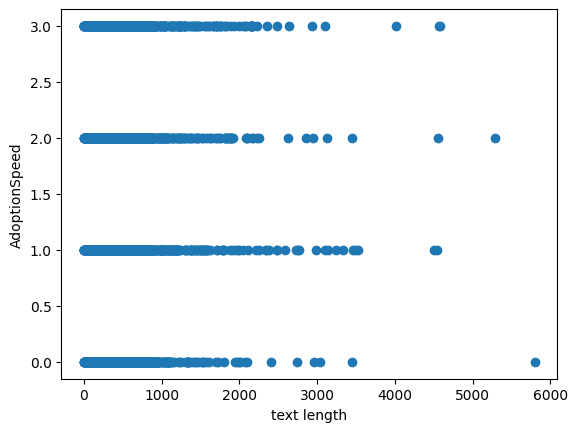

In [13]:
fig = plt.scatter(train_df['text_len'], train_df['AdoptionSpeed'])
plt.xlabel('text length')
plt.ylabel('AdoptionSpeed')
plt.show()

### 1.4 Check class balance

In [14]:
train_df['AdoptionSpeed'].value_counts(normalize=True)

### 1.5 Quadratic Weighted Kappa (QWK)

In [17]:
def confusion_matrix(rater_a, rater_b, min_rating=None, max_rating=None):
    """
    Returns the confusion matrix between rater's ratings
    """
    assert (len(rater_a) == len(rater_b))
    if min_rating is None:
        min_rating = min(rater_a + rater_b)
    if max_rating is None:
        max_rating = max(rater_a + rater_b)
    num_ratings = int(max_rating - min_rating + 1)
    conf_mat = [[0 for i in range(num_ratings)]
                for j in range(num_ratings)]
    for a, b in zip(rater_a, rater_b):
        conf_mat[a - min_rating][b - min_rating] += 1
    return conf_mat


def histogram(ratings, min_rating=None, max_rating=None):
    """
    Returns the counts of each type of rating that a rater made
    """
    if min_rating is None:
        min_rating = min(ratings)
    if max_rating is None:
        max_rating = max(ratings)
    num_ratings = int(max_rating - min_rating + 1)
    hist_ratings = [0 for x in range(num_ratings)]
    for r in ratings:
        hist_ratings[r - min_rating] += 1
    return hist_ratings


def quadratic_weighted_kappa(y, y_pred):
    """
    Calculates the quadratic weighted kappa
    axquadratic_weighted_kappa calculates the quadratic weighted kappa
    value, which is a measure of inter-rater agreement between two raters
    that provide discrete numeric ratings.  Potential values range from -1
    (representing complete disagreement) to 1 (representing complete
    agreement).  A kappa value of 0 is expected if all agreement is due to
    chance.
    quadratic_weighted_kappa(rater_a, rater_b), where rater_a and rater_b
    each correspond to a list of integer ratings.  These lists must have the
    same length.
    The ratings should be integers, and it is assumed that they contain
    the complete range of possible ratings.
    quadratic_weighted_kappa(X, min_rating, max_rating), where min_rating
    is the minimum possible rating, and max_rating is the maximum possible
    rating
    """
    rater_a = y
    rater_b = y_pred
    min_rating = None
    max_rating = None
    rater_a = np.array(rater_a, dtype=int)
    rater_b = np.array(rater_b, dtype=int)
    assert (len(rater_a) == len(rater_b))
    if min_rating is None:
        min_rating = min(min(rater_a), min(rater_b))
    if max_rating is None:
        max_rating = max(max(rater_a), max(rater_b))
    conf_mat = confusion_matrix(rater_a, rater_b,
                                min_rating, max_rating)
    num_ratings = len(conf_mat)
    num_scored_items = float(len(rater_a))

    hist_rater_a = histogram(rater_a, min_rating, max_rating)
    hist_rater_b = histogram(rater_b, min_rating, max_rating)

    numerator = 0.0
    denominator = 0.0

    for i in range(num_ratings):
        for j in range(num_ratings):
            expected_count = (hist_rater_a[i] * hist_rater_b[j]
                              / num_scored_items)
            d = pow(i - j, 2.0) / pow(num_ratings - 1, 2.0)
            numerator += d * conf_mat[i][j] / num_scored_items
            denominator += d * expected_count / num_scored_items

    return (1.0 - numerator / denominator)

### 1.6 Train/validation split

In [18]:
train_data, valid_data, train_labels, valid_labels = train_test_split(
    train_df[['PetID', 'Description']], train_df['AdoptionSpeed'], test_size=0.2, random_state=6, stratify=train_df['AdoptionSpeed'])

test_data = test_df['Description']

## 2. Text Modeling Pipeline

The first modeling branch uses pet profile descriptions as input. This part covers tokenization, dataset preparation, transformer fine-tuning, and validation performance for the text-only approach.

### 2.1 Transformer and training setup

In [83]:
max_length = 512
device = torch.device(
    'cuda') if torch.cuda.is_available() else torch.device('cpu')
batch_size = 128

In [40]:
model_name = 'roberta-base'
model = RobertaForSequenceClassification.from_pretrained(
    model_name, num_labels=4)
tokenizer = RobertaTokenizer.from_pretrained(model_name)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [41]:
for name, param in model.named_parameters():
    if "classifier" not in name:  # Check if the parameter is part of the classifier
        param.requires_grad = False

### 2.2 Tokenization, dataset, and dataloaders

In [19]:
def tokenize(examples):
    return tokenizer(
        examples,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

In [20]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenize(str(self.texts[idx]))
        if self.labels is not None:
            return {'input_ids': encoding['input_ids'].squeeze(), 'attention_mask': encoding['attention_mask'].squeeze(), 'labels': torch.tensor(int(self.labels[idx]))}
        return {'input_ids': encoding['input_ids'].squeeze(), 'attention_mask': encoding['attention_mask'].squeeze()}

In [86]:
train_text_dataset = CustomDataset(
    train_data['Description'].tolist(), train_labels.tolist())
train_text_loader = DataLoader(train_text_dataset, batch_size=batch_size, shuffle=True)

valid_text_dataset = CustomDataset(
    valid_data['Description'].tolist(), valid_labels.tolist())
valid_text_loader = DataLoader(valid_text_dataset, batch_size=batch_size)

In [61]:
d = next(iter(train_text_loader))
print(d['input_ids'].shape)
print(d['attention_mask'].shape)
print(d['labels'].shape)

torch.Size([64, 512])
torch.Size([64, 512])
torch.Size([64])


### 2.3 Text model training loop

In [46]:
torch.cuda.empty_cache()
gc.collect()

961

In [47]:

# Wrap model with DataParallel for multi-GPU support
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to('cuda:0')  # Ensure model is on the default GPU (cuda:0)


Using 2 GPUs


In [49]:
lr = 1e-5
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

In [50]:
def evaluate_text(model, valid_loader, criterion=None, return_loss=True):
        
    model.eval()
    predictions = []
    true_labels = []
    epoch_loss = 0
    
    with torch.no_grad():
        for i, batch in tqdm(enumerate(valid_loader)):
            inputs = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            if return_loss: 
                labels = batch['labels'].to(device)
                true_labels.extend(labels.cpu().numpy())
            
            outputs = model(
                input_ids=inputs, attention_mask=attention_mask, return_dict=True)
            logits = outputs['logits']
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            
            predictions.extend(preds)
            

            if return_loss: 
                loss = criterion(logits, labels)
                epoch_loss += loss.item()
    
    if return_loss: return predictions, true_labels, epoch_loss
    return predictions

In [51]:
epochs = 6

train_losses, valid_losses = [], []
best_val_loss = float('inf')

for epoch in tqdm(range(epochs)):
    epoch_loss = 0
    
    
    for i, batch in tqdm(enumerate(train_text_loader)):
        optimizer.zero_grad()
        inputs = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
            
        outputs = model(input_ids=inputs, attention_mask=attention_mask, labels=labels, return_dict=True)
        loss = criterion(outputs['logits'], labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss/len(train_text_loader))
    model.eval()
        
    predictions, true_labels, epoch_loss = evaluate_text(model, valid_text_loader, criterion)
    
    valid_loss = epoch_loss / len(valid_text_loader)
    valid_losses.append(valid_loss)

    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        model_name = 'roberta_freeze.pth'
        if torch.cuda.device_count() > 1:
            torch.save(model.module.state_dict(), model_name)
        else:
            torch.save(model.state_dict(), model_name)

    qwk = quadratic_weighted_kappa(true_labels, predictions)
    print(f'Quadratic Weighted Kappa: {qwk:.4f}')
    print(f'Epoch {epoch+1}/{epochs} train loss: {train_losses[-1]:.4f} validation loss: {valid_losses[-1]:.4f}')

  0%|          | 0/6 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Quadratic Weighted Kappa: 0.0000
Epoch 1/6 train loss: 1.3919 validation loss: 1.3705


0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

Quadratic Weighted Kappa: 0.0000
Epoch 5/6 train loss: 1.3571 validation loss: 1.3586


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Quadratic Weighted Kappa: 0.0000
Epoch 6/6 train loss: 1.3556 validation loss: 1.3577


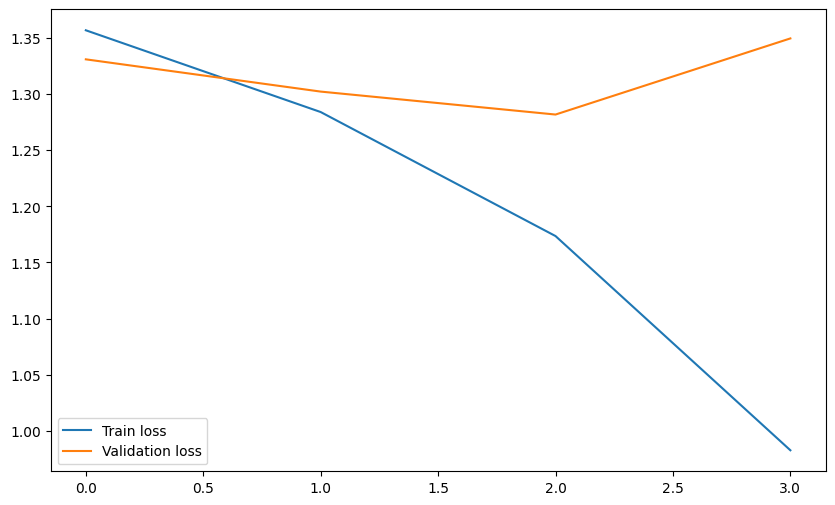

In [34]:
figure = plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train loss")
plt.plot(valid_losses, label="Validation loss")
plt.legend()
plt.show()

In [ ]:
%cd /kaggle/working
from IPython.display import FileLink 
FileLink(r'best_model_weights_bert.pth')

## 3. Image Modeling Pipeline

The second branch focuses on pet photos. I prepare image datasets, define computer-vision models, and train an image-only classifier to compare against the text-based solution.

In [21]:
img_train_dir = '/kaggle/input/fp-img/images/images/train'
img_test_dir = '/kaggle/input/fp-img/images/images/test'

### 3.1 Image dataset and augmentations

In [22]:
train_transformer = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])             

test_transformer = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

In [24]:
class ImgDataset(Dataset):
    def __init__(self, img_names, img_dir, labels=None, transform=None):
        self.img_names = img_names
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, index):
        img_name = self.img_names[index]  # Get image_name
        label = self.labels[index] if self.labels is not None else 0      # Get label
        img_path = os.path.join(self.img_dir, img_name)
        
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
        except (FileNotFoundError, OSError):
            # Return an empty tensor and None for the label if the image doesn't exist
            image = torch.empty(3, 224, 224)  # Adjust size if necessary
        
        
        return image, label

### 3.2 Dataset setup (first image per pet)

In [23]:
valid_img_data = pd.DataFrame()
valid_img_data['Img_name'] = valid_data['PetID'] + '-1.jpg'
# valid_df
valid_img_data['Labels'] = valid_labels

train_img_data = pd.DataFrame()
train_img_data['Img_name'] = train_data['PetID'] + '-1.jpg'
# valid_df
train_img_data['Labels'] = train_labels

In [80]:
img_batch_size = 128

In [82]:
# Create train and test datasets
train_img_dataset = ImgDataset(train_img_data['Img_name'].tolist(), labels=train_img_data['Labels'].tolist(), img_dir=img_train_dir, transform=train_transformer)
valid_img_dataset = ImgDataset(valid_img_data['Img_name'].tolist(), labels=valid_img_data['Labels'].tolist(), img_dir=img_train_dir, transform=test_transformer)

# Create DataLoaders
train_img_loader = DataLoader(train_img_dataset, batch_size=img_batch_size, shuffle=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=img_batch_size, shuffle=False)

In [35]:
next(iter(train_img_loader))

[tensor([[[[ 1.9749,  1.9749,  2.0092,  ...,  1.9749,  1.9578,  1.9749],
           [ 2.0948,  2.1290,  2.1119,  ...,  2.0777,  2.0948,  2.0948],
           [ 2.0777,  2.1119,  2.1119,  ...,  2.0777,  2.0605,  2.0434],
           ...,
           [ 2.0434,  2.0605,  2.0434,  ...,  2.0263,  2.0605,  2.0263],
           [ 2.0434,  2.0092,  2.0434,  ...,  2.0263,  2.0263,  1.9920],
           [ 2.0092,  1.9920,  2.0434,  ...,  2.0092,  2.0263,  2.0605]],
 
          [[ 2.1485,  2.1485,  2.1835,  ...,  2.1485,  2.1310,  2.1485],
           [ 2.2710,  2.3060,  2.2885,  ...,  2.2535,  2.2710,  2.2710],
           [ 2.2535,  2.2885,  2.2885,  ...,  2.2535,  2.2360,  2.2185],
           ...,
           [ 2.2185,  2.2360,  2.2185,  ...,  2.2010,  2.2360,  2.2010],
           [ 2.2185,  2.1835,  2.2185,  ...,  2.2010,  2.2010,  2.1660],
           [ 2.1835,  2.1660,  2.2185,  ...,  2.1835,  2.2010,  2.2360]],
 
          [[ 2.3611,  2.3611,  2.3960,  ...,  2.3611,  2.3437,  2.3611],
           [ 

### 3.3 Dataset setup (all images per pet)

In [ ]:
batch_size = 64

img_df = pd.DataFrame([img for img in os.listdir(img_dir_train)], columns=['Img_name'])
img_df['PetID'] = img_df['Img_name'].apply(lambda x: x.split('-')[0])
img_df = pd.merge(img_df, train_df[['PetID', 'AdoptionSpeed']], on='PetID', how='left')

all_valid_img_data = pd.merge(valid_data.drop(['Description'], axis=1), img_df, on='PetID', how='inner')
all_train_img_data = pd.merge(train_data.drop(['Description'], axis=1), img_df, on='PetID', how='inner')

all_train_img_dataset = ImgDataset(all_train_img_data['Img_name'].tolist(), labels=all_train_img_data['AdoptionSpeed'].tolist(), img_dir=img_train_dir, transform=train_transformer)
all_valid_img_dataset = ImgDataset(all_valid_img_data['Img_name'].tolist(), labels=all_valid_img_data['AdoptionSpeed'].tolist(), img_dir=img_train_dir, transform=test_transformer)

# Create DataLoaders
all_train_img_loader = DataLoader(all_train_img_dataset, batch_size=batch_size, shuffle=True)
all_valid_img_loader = DataLoader(all_valid_img_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
next(iter(all_train_img_loader))    

### 3.4 Vision model definition

In [ ]:
class EfficientNetModel(nn.Module):
    def __init__(self, model_type='b0', num_classes=4, freeze=True):
        super(EfficientNetModel, self).__init__()

        # Load the specified pre-trained EfficientNet model
        if model_type == 'b0':
            self.efficientnet = models.efficientnet_b0(pretrained=True)
        elif model_type == 'b1':
            self.efficientnet = models.efficientnet_b1(pretrained=True)
        elif model_type == 'b2':
            self.efficientnet = models.efficientnet_b2(pretrained=True)
        elif model_type == 'b3':
            self.efficientnet = models.efficientnet_b3(pretrained=True)
        elif model_type == 'b4':
            self.efficientnet = models.efficientnet_b4(pretrained=True)
        elif model_type == 'b5':
            self.efficientnet = models.efficientnet_b5(pretrained=True)
        elif model_type == 'b6':
            self.efficientnet = models.efficientnet_b6(pretrained=True)
        elif model_type == 'b7':
            self.efficientnet = models.efficientnet_b7(pretrained=True)
        else:
            raise ValueError(f"Invalid model type: {model_type}. Choose from 'b0' to 'b7'.")

        # Replace the final classification layer
        in_features = self.efficientnet.classifier[-1].in_features
        self.efficientnet.classifier = nn.Linear(in_features, num_classes)

        # Freeze all layers except the classifier
        if freeze:
            for param in self.efficientnet.parameters():
                param.requires_grad = False
            # Unfreeze the classifier layer
            for param in self.efficientnet.classifier.parameters():
                param.requires_grad = True

    def forward(self, images):
        return self.efficientnet(images)

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 4  # Change this to your number of labels
model = models.resnet50(pretrained=True)  # You can use resnet50 or other variants
model.fc = nn.Linear(model.fc.in_features, num_classes)  # Modify the final layer

In [55]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetModel(model_type='b2', freeze=False)

In [37]:
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to('cuda:0')

Using 2 GPUs


### 3.5 Training and evaluation loops

In [31]:
def evaluate_imgs(model, loader, criterion=None, return_loss=True):
        
    model.eval()
    y_true = []
    y_pred = []
    epoch_loss = 0

    with torch.no_grad():  # No need to track gradients during evaluation
        for i, batch in tqdm(enumerate(loader)):  # Ensure img_valid_loader is consistent
            images = batch[0].to(device) 
            if return_loss:labels = batch[1].to(device)  # Move data to device
            
            outputs = model(images)
            
            if return_loss:
                loss = criterion(outputs, labels)
                epoch_loss += loss.item()
                y_true.extend(labels.cpu().numpy())

            _, predicted = torch.max(outputs.data, 1)
            
              # Store true labels
            y_pred.extend(predicted.cpu().numpy())  # Store predicted labels
    
    if return_loss: return y_pred, y_true, epoch_loss
    return y_pred
    

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

best_val_loss = float('inf')
train_losses = []
valid_losses = []

num_epochs = 10
for epoch in tqdm(range(num_epochs)):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    
    for images, labels in tqdm(train_img_loader):  # Ensure img_train_loader is consistent
        images, labels = images.to(device), labels.to(device)  # Move data to the same device

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_img_loader)  # Use correct loader variable
    train_losses.append(avg_loss)

    y_pred, y_true, epoch_loss = evaluate_imgs(model, valid_img_loader, criterion, return_loss=True)
    valid_loss = epoch_loss / len(valid_img_loader)  # Use correct loader variable
    valid_losses.append(valid_loss)

    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        model_name = 'effb1_all.pth'
        if torch.cuda.device_count() > 1:
            torch.save(model.module.state_dict(), model_name)
        else:
            torch.save(model.state_dict(), model_name)

    qwk = quadratic_weighted_kappa(y_true, y_pred)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_loss:.4f}, Validation Loss: {valid_loss:.4f}, Validation QWK: {qwk:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

Epoch [1/10], Train Loss: 1.2852, Validation Loss: 1.3585, Validation QWK: 0.3588


  0%|          | 0/41 [00:00<?, ?it/s]

...

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

Epoch [9/10], Train Loss: 0.1143, Validation Loss: 2.7547, Validation QWK: 0.3865


  0%|          | 0/41 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 4. Validation-Time Fusion of Text and Image Models

Here I combine predictions from the text and image branches on the validation split. The goal is to test simple late-fusion strategies and see whether multimodal signals improve ranking quality compared with single-modality models.

### 4.1 Load trained models

In [ ]:
num_classes = 4

checkpoint = 'roberta-base'
model_text = RobertaForSequenceClassification.from_pretrained(
    checkpoint, num_labels=num_classes)
tokenizer = RobertaTokenizer.from_pretrained(checkpoint)
model_text.load_state_dict(torch.load('best_model_weights_roberta.pth', map_location=torch.device('cpu')))

In [ ]:
model_img = models.resnet101(pretrained=True).to(device)  # You can use resnet50 or other variants
model_img.fc = nn.Linear(model_img.fc.in_features, num_classes)
model_img.load_state_dict(torch.load('best_model_weights_resnet101_all_lastlayer.pth', map_location=torch.device('cpu')))

In [ ]:
model_img = EfficientNetModel(model_type='b2', num_classes=4, freeze=False).to(device)
model_img.load_state_dict(torch.load('effb2_alldata.pth', map_location=torch.device('cpu')))

In [ ]:
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model_img = model.to('cuda:0')

### 4.2 Generate validation predictions

In [45]:
text_preds = evaluate_text(model_text, valid_text_loader, return_loss=False)

0it [00:00, ?it/s]

In [49]:
img_preds = evaluate_imgs(model_img, valid_img_loader, return_loss=False)

  0%|          | 0/21 [00:00<?, ?it/s]

### 4.3 Compare late-fusion strategies

In [50]:
res_df = pd.DataFrame({'PetID': valid_data['PetID'], 'True_label':valid_labels})
res_df

,PetID,True_label
2461,6ac7e0c51,3
3581,a2fecc9a4,0
5548,ab87287a4,3
6331,91c4cb54d,1
4541,54e0ac09d,3
...,...,...
2192,b05d0484f,0
6214,f91147e5f,3
4631,83defd365,0
2737,468cec390,1


In [51]:
res_df['Text_pred'] = text_preds
res_df['Img_pred'] = img_preds
res_df

,PetID,True_label,Text_pred,Img_pred
2461,6ac7e0c51,3,3,3
3581,a2fecc9a4,0,1,1
5548,ab87287a4,3,1,3
6331,91c4cb54d,1,3,3
4541,54e0ac09d,3,1,3
...,...,...,...,...
2192,b05d0484f,0,1,1
6214,f91147e5f,3,3,0
4631,83defd365,0,1,2
2737,468cec390,1,2,1


In [52]:
res_df['avg_pred'] = res_df[['Img_pred', 'Text_pred']].mean(axis=1).astype(int)
res_df['avg_up_pred'] = np.ceil(res_df[['Img_pred', 'Text_pred']].mean(axis=1)).astype(int)
res_df['max_pred'] = res_df[['Img_pred', 'Text_pred']].max(axis=1)
res_df['min_pred'] = res_df[['Img_pred', 'Text_pred']].min(axis=1)
res_df

,PetID,True_label,Text_pred,Img_pred,avg_pred,avg_up_pred,max_pred,min_pred
2461,6ac7e0c51,3,3,3,3,3,3,3
3581,a2fecc9a4,0,1,1,1,1,1,1
5548,ab87287a4,3,1,3,2,2,3,1
6331,91c4cb54d,1,3,3,3,3,3,3
4541,54e0ac09d,3,1,3,2,2,3,1
...,...,...,...,...,...,...,...,...
2192,b05d0484f,0,1,1,1,1,1,1
6214,f91147e5f,3,3,0,1,2,3,0
4631,83defd365,0,1,2,1,2,2,1
2737,468cec390,1,2,1,1,2,2,1


In [53]:
sum_cols = ['Img_pred', 'Text_pred', 'avg_pred', 'avg_up_pred', 'max_pred', 'min_pred']
qwks = {}
for col in sum_cols:
    qwks[col] = quadratic_weighted_kappa(res_df['True_label'], res_df[col])
qwks

{'Img_pred': 0.47429880295459315,
 'Text_pred': 0.30505947944306966,
 'avg_pred': 0.47996943266082526,
 'avg_up_pred': 0.43778232898478153,
 'max_pred': 0.3458407849263453,
 'min_pred': 0.4390984308656324}

## 4.4 Validation Results with All Images per Pet

In [ ]:
model_img = EfficientNetModel(model_type='b2', num_classes=4, freeze=False).to(device)
model_img.load_state_dict(torch.load('effb2_alldata.pth', map_location=torch.device('cpu')))

In [ ]:
img_all_preds = evaluate_imgs(model_img, all_valid_img_loader, return_loss=False)

In [ ]:
res_all_img = all_valid_img_data.copy()
res_all_img['Preds'] = img_all_preds
res_all_img

In [ ]:
collapsed_df = res_all_img.groupby('PetID').agg({
    'AdoptionSpeed': 'first',               # Take the first 'AdoptionSpeed'
    'Preds': [('mean', lambda x: round(x.mean())),  # Compute mean for 'Preds' and round
              ('max', 'max')]        # Compute max for 'Preds'
}).reset_index()

# Flatten the multi-level column names (if necessary)
collapsed_df.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in collapsed_df.columns]
collapsed_df

In [ ]:
sum_cols = ['Preds_mean', 'Preds_max']
qwks = {}
for col in sum_cols:
    qwks[col] = quadratic_weighted_kappa(collapsed_df['AdoptionSpeed_first'], collapsed_df[col])
qwks

## 5. End-to-End Multimodal Model

In addition to late fusion, I also experiment with a joint multimodal architecture that processes both text and images in a single training pipeline.

### 5.1 Multimodal architecture

In [25]:
class MultiCopy(nn.Module):
    def __init__(self, projection_dim=512, num_classes=4):
        super().__init__()
        
        # RoBERTa part (text)
        self.text_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=num_classes)

#         Load pre-trained weights for RoBERTa
#         self.text_model.load_state_dict(torch.load('/kaggle/input/roberta/pytorch/default/1/best_model_weights_roberta.pth'), strict=False)

#         Freeze RoBERTa parameters
#         for param in self.text_model.parameters():
#             param.requires_grad = False
            
        # Projection layer for RoBERTa
        self.text_projection = nn.Linear(self.text_model.config.hidden_size, projection_dim)

        # EfficientNet part (image)
        self.img_model = models.resnet101(pretrained=True)  # You can use resnet50 or other variants
        for param in self.img_model.parameters():
            param.requires_grad = False  
        
        # Image feature extractor (removing the final classification layer from EfficientNet)
        self.img_feature_extractor = nn.Sequential(*list(self.img_model.children())[:-1])
        dummy_input = torch.randn(1, 3, 224, 224)  # Dummy input for feature extraction
        dummy_output = self.img_feature_extractor(dummy_input)
        num_img_features = dummy_output.shape[1]
        
        # Projection layer for image features
        self.image_projection = nn.Linear(num_img_features, projection_dim)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(projection_dim * 2, projection_dim),  # Combine and reduce to 512
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(projection_dim, num_classes)
        )   
        
    def forward(self, input_ids, attention_mask, images):
        # RoBERTa forward pass for text (get hidden states)
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)

        # Get embeddings from the penultimate layer
        hidden_states = text_outputs.hidden_states  # Access all hidden states
        text_embeddings = hidden_states[-2][:, 0, :]  # Get the CLS token from the penultimate layer
        
        text_proj = self.text_projection(text_embeddings)
        
        # EfficientNet forward pass for images
        image_features = self.img_feature_extractor(images)
        image_features = image_features.view(image_features.size(0), -1)  # Flatten features
        image_proj = self.image_projection(image_features)

        # Concatenate projected text and image embeddings
        combined_features = torch.cat((text_proj, image_proj), dim=1)

        # Final classification
        logits = self.classifier(combined_features)
        return logits


In [29]:
model = MultiCopy(projection_dim=512)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to('cuda:0')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:01<00:00, 143MB/s]  


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### 5.2 Multimodal data preparation

In [28]:
batch_size = 64
max_length = 128
train_text_dataset = CustomDataset(
    train_data['Description'].tolist(), train_labels.tolist())
train_text_loader = DataLoader(train_text_dataset, batch_size=batch_size, shuffle=True)

valid_text_dataset = CustomDataset(
    valid_data['Description'].tolist(), valid_labels.tolist())
valid_text_loader = DataLoader(valid_text_dataset, batch_size=batch_size)

train_img_dataset = ImgDataset(train_img_data['Img_name'].tolist(), labels=train_img_data['Labels'].tolist(), img_dir=img_train_dir, transform=train_transformer)
valid_img_dataset = ImgDataset(valid_img_data['Img_name'].tolist(), labels=valid_img_data['Labels'].tolist(), img_dir=img_train_dir, transform=test_transformer)

# Create DataLoaders
train_img_loader = DataLoader(train_img_dataset, batch_size=batch_size, shuffle=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=batch_size, shuffle=False)

### 5.3 Multimodal training and evaluation

In [26]:
def evaluate_multimodal(model, valid_text_loader, valid_img_loader, criterion):
    model.eval()
    val_loss = 0.0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for text_batch, image_batch in tqdm(zip(valid_text_loader, valid_img_loader)):
            input_ids = text_batch['input_ids'].to(device)
            attention_mask = text_batch['attention_mask'].to(device)
            labels = text_batch['labels'].to(device)
            
            images = image_batch[0].to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, images=images)
            
            # Loss computation
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Predictions
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    avg_val_loss = val_loss / len(valid_text_loader)
    return predictions, true_labels, avg_val_loss

In [90]:
torch.cuda.empty_cache()
gc.collect()

1595

In [ ]:
num_epochs = 25

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-3  # or adjust the learning rate as needed
)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_qwk = 0

predictions = {}

for epoch in tqdm(range(num_epochs)):
    model.train()
    running_loss = 0.0
    
    for text_batch, image_batch in tqdm(zip(train_text_loader, train_img_loader), total=len(train_text_loader), desc=f'Epoch {epoch+1}/{num_epochs}'):
        # Text data
        input_ids = text_batch['input_ids'].to(device)
        attention_mask = text_batch['attention_mask'].to(device)
        labels = text_batch['labels'].to(device)
        
        # Image data
        images = image_batch[0].to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, images=images)
        
        # Loss computation
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_text_loader)
    train_losses.append(avg_train_loss)
    # Evaluation
    val_predictions, val_true_labels, val_loss = evaluate_multimodal(model, valid_text_loader, valid_img_loader, criterion)
    val_losses.append(val_loss)
    predictions[epoch] = val_predictions
    
    qwk = quadratic_weighted_kappa(val_true_labels, val_predictions)
    
    if qwk > best_qwk:
        best_qwk = qwk
        model_name = 'best_multi_distil-unfreeze.pt'
        if torch.cuda.device_count() > 1:
            torch.save(model.module.state_dict(), model_name)
        else:
            torch.save(model.state_dict(), model_name)
    
    
    print(f"Epoch {epoch+1}/{num_epochs}, train_loss: {avg_train_loss:.4f}, val_loss: {val_loss:.4f}, val_qwk: {qwk:.4f}")

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25:   0%|          | 0/81 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Epoch 1/25, train_loss: 1.4065, val_loss: 1.3654, val_qwk: -0.0004


Epoch 2/25:   0%|          | 0/81 [00:00<?, ?it/s]

...

Epoch 6/25, train_loss: 1.3644, val_loss: 1.3638, val_qwk: 0.0000


Epoch 7/25:   0%|          | 0/81 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Epoch 7/25, train_loss: 1.3653, val_loss: 1.3611, val_qwk: 0.0000


Epoch 8/25:   0%|          | 0/81 [00:00<?, ?it/s]

In [78]:
losses = pd.DataFrame({'train_loss': train_losses, 'val_loss': val_losses})
losses.to_csv('losses.csv', index=False)

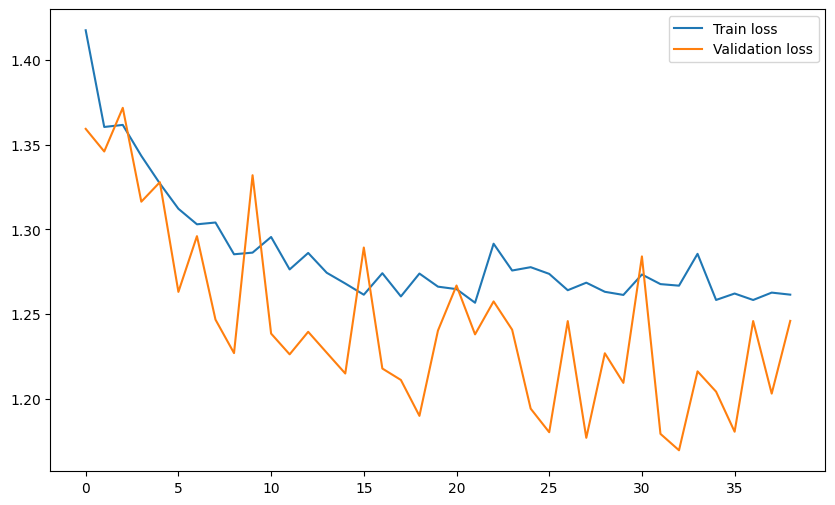

In [76]:
figure = plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.legend()
plt.show()

## 6. Test-Set Inference and Submission Files

After validating the individual approaches, this section generates predictions for the competition test set and prepares submission-ready CSV files.

In [ ]:
batch_size = 64

### 6.1 Text-only test predictions

In [ ]:
test_text_dataset = CustomDataset(test_df['Description'].tolist())
test_text_loader = DataLoader(test_text_dataset, batch_size=batch_size)

In [ ]:
num_classes = 4

checkpoint = 'roberta-base'
model_text = RobertaForSequenceClassification.from_pretrained(
    checkpoint, num_labels=num_classes)
tokenizer = RobertaTokenizer.from_pretrained(checkpoint)
model_text.load_state_dict(torch.load('best_model_weights_roberta.pth', map_location=torch.device('cpu')))

In [ ]:
text_preds = evaluate_text(model_text, test_text_loader)

In [ ]:
test_df['AdoptionSpeed'] = text_preds
test_df['AdoptionSpeed'] = test_df['AdoptionSpeed'] + 1
submission = test_df.drop('Description', axis=1)
submission.to_csv('submission_text.csv', index=False, header=True)
submission

### 6.2 First-image test predictions

In [ ]:
test_img_data = pd.DataFrame()
test_img_data['Img_name'] = test_df['PetID'] + '-1.jpg'

test_img_dataset = ImgDataset(test_img_data['Img_name'].tolist(), img_dir=img_test_dir, transform=test_transformer, labels=None)

test_img_loader = DataLoader(test_img_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
model_img = models.resnet101(pretrained=True).to(device)  # You can use resnet50 or other variants
model_img.fc = nn.Linear(model_img.fc.in_features, num_classes)
model_img.load_state_dict(torch.load('best_model_weights_resnet101_all_lastlayer.pth', map_location=torch.device('cpu')))

In [ ]:
img_preds = evaluate_multimodal(model_img, test_img_loader, return_loss=False)

In [ ]:
test_df['AdoptionSpeed'] = img_preds
test_df['AdoptionSpeed'] = test_df['AdoptionSpeed'] + 1
submission = test_df.drop('Description', axis=1)
submission.to_csv('submission_img.csv', index=False, header=True)
submission

### 6.3 All-images test predictions

In [ ]:
all_test_img_df = pd.DataFrame([img for img in os.listdir(img_dir_test)], columns=['Img_name'])
all_test_img_df['PetID'] = all_test_img_df['Img_name'].apply(lambda x: x.split('-')[0])

all_test_img_dataset = ImgDataset(all_test_img_df['Img_name'].tolist(), img_dir=img_test_dir, transform=test_transformer)

all_test_img_loader = DataLoader(all_test_img_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
model_img = EfficientNetModel(model_type='b2', num_classes=4, freeze=False).to(device)
model_img.load_state_dict(torch.load('effb2_alldata.pth', map_location=torch.device('cpu')))

In [ ]:
all_img_preds = evaluate_imgs(model_img, all_test_img_loader, return_loss=False)

In [ ]:
res_all_img = all_test_img_df.copy()
res_all_img['Preds'] = all_img_preds

test_preds_df = res_all_img.groupby('PetID').agg({
    'Preds': [('mean', lambda x: round(x.mean())),
              ('max', 'max') ]       # Compute max for 'Preds'
}).reset_index()

test_preds_df.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in test_preds_df.columns]

test_preds_df

In [ ]:
all_img_test_mean = pd.DataFrame({'PetID': test_preds_df['PetID_'], 'AdoptionSpeed': test_preds_df['Preds_mean']}) 
all_img_test_max = pd.DataFrame({'PetID': test_preds_df['PetID_'], 'AdoptionSpeed': test_preds_df['Preds_max']})

all_img_test_mean = pd.merge(test_df.drop(['AdoptionSpeed', 'Description'], axis=1), all_img_test_mean, on='PetID', how='left')
all_img_test_max = pd.merge(test_df.drop(['AdoptionSpeed', 'Description'], axis=1), all_img_test_max, on='PetID', how='left')

all_img_test_mean.fillna(0, inplace=True)
all_img_test_max.fillna(0, inplace=True)

all_img_test_mean['AdoptionSpeed'] = all_img_test_mean['AdoptionSpeed'].astype(int) + 1
all_img_test_max['AdoptionSpeed'] = all_img_test_max['AdoptionSpeed'].astype(int) + 1

all_img_test_mean

In [ ]:
all_img_test_mean.to_csv('submission_all_img_efb2_mean.csv', index=False, header=True)
all_img_test_max.to_csv('submission_all_img_efb2_max.csv', index=False, header=True)

### 6.4 Multimodal test predictions

This subsection generates test-set predictions using the end-to-end multimodal model and writes the final submission output.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiCopy(projection_dim=512)
# model.load_state_dict(torch.load('best_multi_e-5.pt', map_location=device))
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

In [ ]:
multi_preds = evaluate_multimodal(model, test_text_loader, test_img_loader, return_loss=False)

In [ ]:
test_df['AdoptionSpeed'] = multi_preds
test_df['AdoptionSpeed'] = test_df['AdoptionSpeed'] + 1
submission = test_df.drop('Description', axis=1)
submission.to_csv('submission_multie05.csv', index=False, header=True)
submission